# Практика 2

**Задание 1.**

Задан Series объект s, найти индекс первого элемента отсортированного s, где значения больше 5.

In [19]:
# задано изначально
import numpy as np
import pandas as pd

r = np.random.RandomState(1)
s = pd.Series(r.uniform(0, 10, 100))
s
s = s.sort_values().reset_index(drop=True)
print(s[s > 5].index[0])

51


**Задание 2.**

Имеется небольшой игрушечный DataFrame, в котором необходимо провести несколько типов фильтраций и отобразить результат:

* всех, кто старше 40
* всех, кто имеет доход выше среднего по датасету
* всех, кто имеет доход выше среднего по датасету, но надежность ниже среднего по датасету

создать новые столбцы:

* важность клиента = доход * надежность
* возможная долгосрочность клиента = важность клиента * (средний возраст по датасету - возраст клиента)

`подсказка: двойные условия записываются так: (условие 1) & (условие 2)`


** примечание: столбцы не имеют отношения к реальным формулам или моделям, они необходимы только для наглядности

In [77]:
# создадим тестовый датасет
import pandas as pd
df = pd.DataFrame({
    'имя': ['Петя', 'Вася', 'Аня', 'Света'],
    'возраст': [45, 26, 41 , 21],
    'доход': [100000, 80000, 150000, 60000],
    'надежность клиента (0..1)': [0.65, 0.74, 0.87, 0.68],
    'пол': ['муж', 'муж', 'жен', 'жен']},
    index=[0, 1, 2, 3])

print(df)

# ваш код тут
print(df[df['возраст'] >= 40])
income_is_higher = df['доход']>df['доход'].mean()
print(df[income_is_higher])
reliability_is_below=df['надежность клиента (0..1)']<df['надежность клиента (0..1)'].mean()
print(df[income_is_higher & reliability_is_below])
# Добавление нового столбца - значения которого переданы в виде списка
df["важность клиента"] = ['65000', '59200', '130500', '40800']
df
df["возможная долгосрочность клиента"] = ['-763760', '429200', '-1011375', '499800']
df

     имя  возраст   доход  надежность клиента (0..1)  пол
0   Петя       45  100000                       0.65  муж
1   Вася       26   80000                       0.74  муж
2    Аня       41  150000                       0.87  жен
3  Света       21   60000                       0.68  жен
    имя  возраст   доход  надежность клиента (0..1)  пол
0  Петя       45  100000                       0.65  муж
2   Аня       41  150000                       0.87  жен
    имя  возраст   доход  надежность клиента (0..1)  пол
0  Петя       45  100000                       0.65  муж
2   Аня       41  150000                       0.87  жен
    имя  возраст   доход  надежность клиента (0..1)  пол
0  Петя       45  100000                       0.65  муж


,имя,возраст,доход,надежность клиента (0..1),пол,важность клиента,возможная долгосрочность клиента
0,Петя,45,100000,0.65,муж,65000,-763760
1,Вася,26,80000,0.74,муж,59200,429200
2,Аня,41,150000,0.87,жен,130500,-1011375
3,Света,21,60000,0.68,жен,40800,499800


**Задание 3.**

Как объединить два DataFrame по двум столбцам так, чтобы остались только общие строки?

Объедините df1 и df2 по столбцам fruit-frukt и weight-ves.

In [90]:
df1 = pd.DataFrame({'fruit': ['apple', 'banana', 'orange'] * 3,
                    'weight': ['low', 'medium', 'high'] * 3,
                    'price': np.random.randint(0, 100, 9)})
print(df1)

df2 = pd.DataFrame({'frukt': ['apple', 'banana', 'melon'] * 2,
                    'ves': ['low', 'high'] * 3,
                    'price': np.random.randint(0, 100, 6)})
print(df2)

pd.merge(df1, df2, how='inner', left_on=['fruit', 'weight'], right_on=['frukt', 'ves'], suffixes=['_left', '_right'], copy=False)

    fruit  weight  price
0   apple     low     91
1  banana  medium     72
2  orange    high     40
3   apple     low     44
4  banana  medium     24
5  orange    high     85
6   apple     low     95
7  banana  medium     57
8  orange    high     12
    frukt   ves  price
0   apple   low     10
1  banana  high     20
2   melon   low     70
3   apple  high     49
4  banana   low     69
5   melon  high      0


,fruit,weight,price_left,frukt,ves,price_right
0,apple,low,91,apple,low,10
1,apple,low,44,apple,low,10
2,apple,low,95,apple,low,10


**Задание 4.** 
Сгенерировать и добавить номера телефонов следующего вида +7(000)000 00 00 в таблицу



In [14]:
import pandas as pd
import re
d = [{"Name": "Виктор", "Age": 18},
     {"Name": "Мария", "Age": 21},
     {"Name": "Иван", "Age": 19},
     {"Name": "Иван", "Age": 25},
     {"Name": "Алексей", "Age": 20}]

df = pd.DataFrame(d)

df
str1='89538679014'
str2='89524456237'
str3='89145678903'
str4='89567342344'
str5='89589345678'
def phone_number(number):
    correct_number = re.sub(r'\+?[78](\d{3})(\d{3})(\d\d)(\d\d)', r'+7(\1)\2-\3-\4', number)
    return correct_number
phone_number1 = phone_number(str1)
phone_number2 = phone_number(str2)
phone_number3 = phone_number(str3)
phone_number4 = phone_number(str4)
phone_number5 = phone_number(str5)
df["Phone"] = [phone_number1, phone_number2, phone_number3, phone_number4, phone_number5]
df

,Name,Age,Phone
0,Виктор,18,+7(953)867-90-14
1,Мария,21,+7(952)445-62-37
2,Иван,19,+7(914)567-89-03
3,Иван,25,+7(956)734-23-44
4,Алексей,20,+7(958)934-56-78


***Задание 1***

Скачать файл по ссылке https://disk.yandex.ru/d/ZeDbB3rqhIr1NA , считать через pandas. Получить список уникальных значений - стран в колонке "Country", отфильтровать и получить данные только по выпускникам колледжа. Убрать строки с пропусками в данных (NaN). (В случае ошибок типов можете конвертировать колонки к нужным типам через .astype(str) или .astype(int). Подсчитать макс значение, среднее и СКО для числа детей (household_children) в отфильтрованных данных.

In [6]:
import pandas as pd

df = pd.read_csv("zadanie1.csv", sep=',')
df
df.hhs_geo_region.unique()
df[df.education == 'College Graduate']
new = df.dropna(axis=0, how='any')
max_children = new.household_children.max()
print(max_children)
average_children = new.household_children.mean()
print(average_children)
df['household_children'].std( )

3.0
0.6422246388068976


0.9281733165470456

***Задание 2***

Скачать файл по ссылке https://disk.yandex.ru/i/uoN5eQE1qPCXCQ , считать через pandas второй лист (Olympics). Отфильтровать данные по России и золотым медалистам, построить график разброса возраст-вид_спорта. Построить линейный график на след данных - df.groupby('Year').Age.mean().dropna(). Сохранить графики в pdf. Отфильтровать изначальные данные только по летнему сезону, убрать колонку Город, создать колонку Год рождения, вычислить её через Возраст и Дату проведения, датафрейм сохранить вместе с графиками в архиве и скачать (командами, не через GUI).

        Sort  Year          Sport Gender           Event             Athlete  \
37315  37315  2014  Alpine Skiing      M        Combined      Sandro Viletta   
37318  37318  2014  Alpine Skiing      F  Super Combined  Maria Hoefl-Riesch   
37321  37321  2014  Alpine Skiing      M        Downhill      Matthias Mayer   
37324  37324  2014  Alpine Skiing      F        Downhill           Tina Maze   
37325  37325  2014  Alpine Skiing      F        Downhill     Dominique Gisin   
...      ...   ...            ...    ...             ...                 ...   
37906  37906  2014  Speed Skating      M    Team Pursuit         Koen Verweu   
37913  37913  2014  Speed Skating      F    Team Pursuit     Marrit Leenstra   
37914  37914  2014  Speed Skating      F    Team Pursuit     Jorien Ter Mors   
37915  37915  2014  Speed Skating      F    Team Pursuit      Lotte Van Beek   
37916  37916  2014  Speed Skating      F    Team Pursuit          Ireen Wust   

        Age           Result Medal   Ci

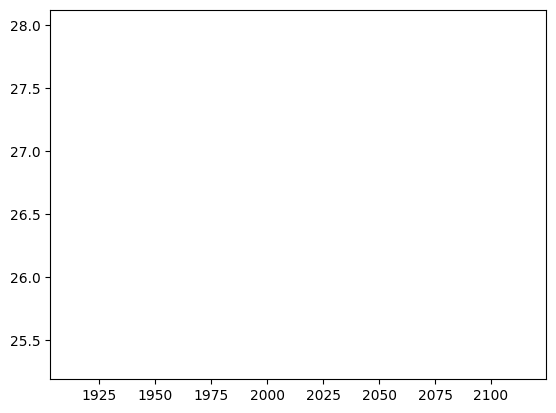

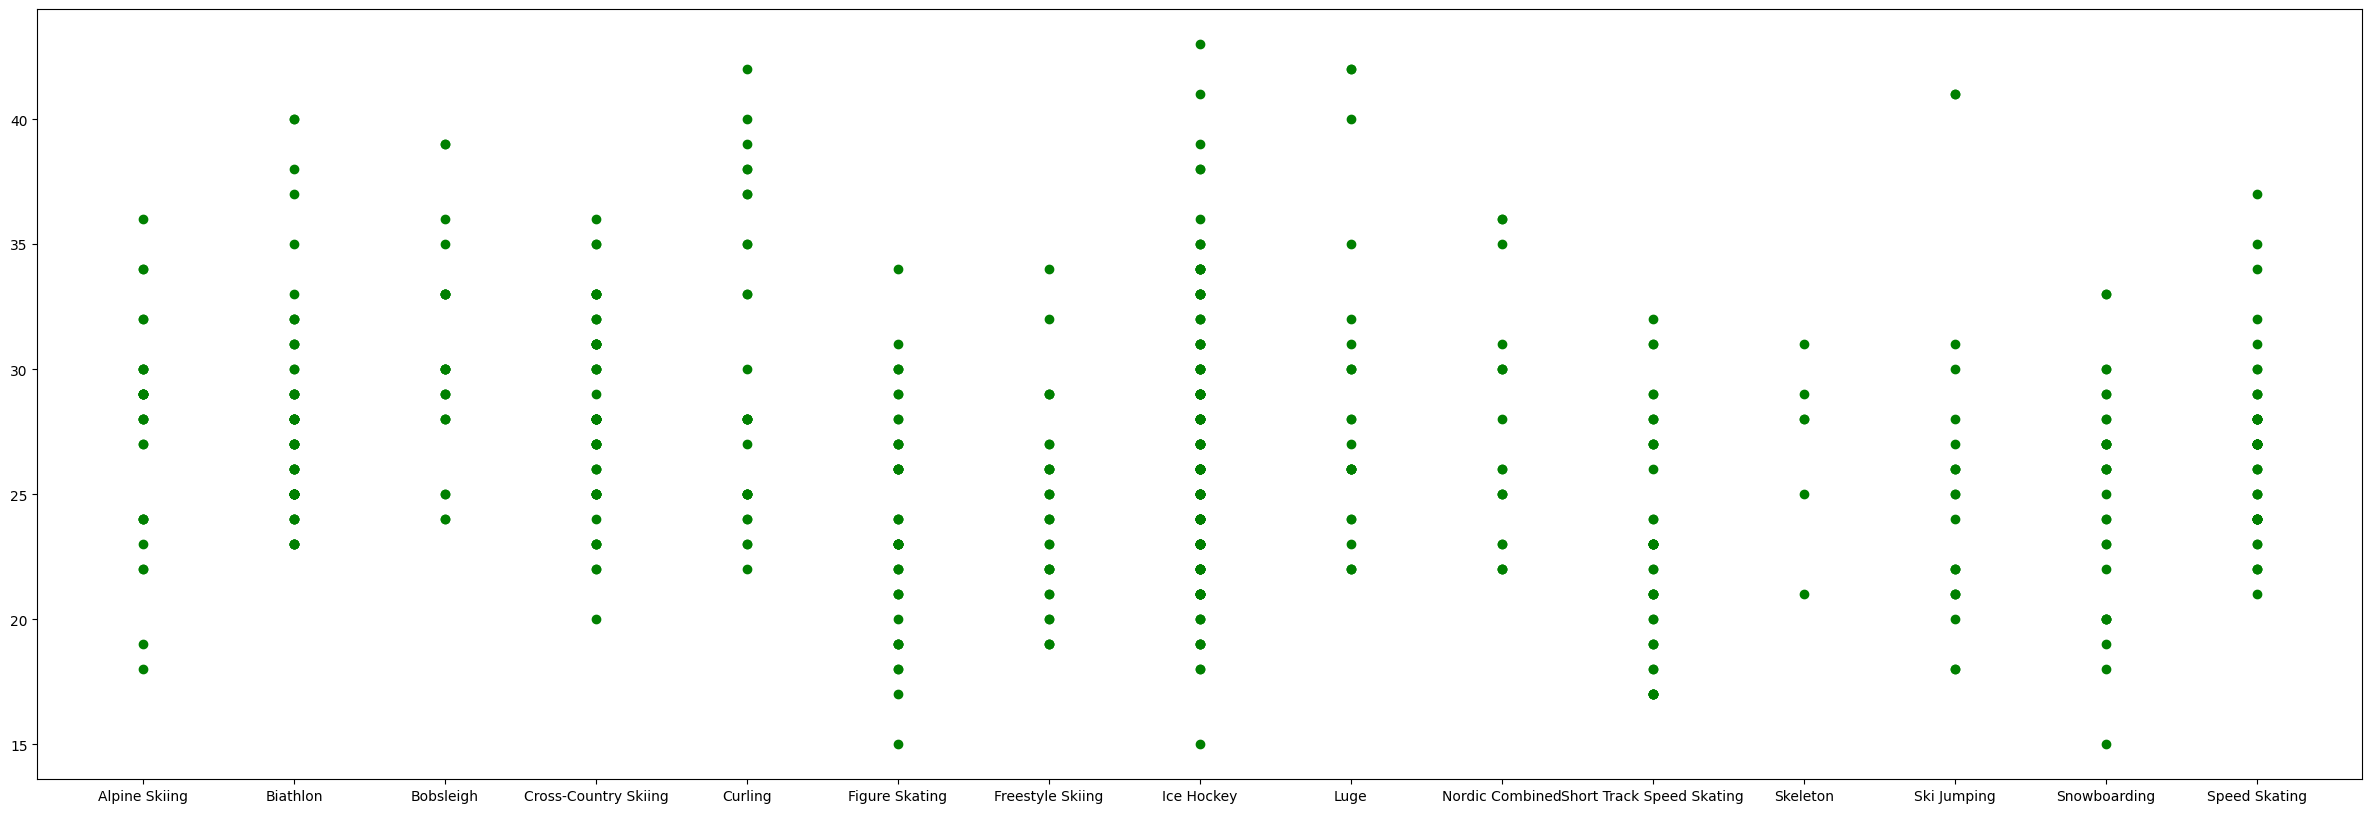

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

xls = pd.read_excel("Olympics 2018.xlsx", sheet_name = 'Olympics')
rus = xls[xls.Country == 'Russia']
medal = rus[rus.Medal == 'GOLD']
print(medal)

plt.plot(medal.groupby('Year').Age.mean().dropna())
plt.savefig('save as pdf1.pdf')
plt.show()

x = rus.Sport
y = rus.Age


fig, ax = plt.subplots()

ax.scatter(x, y, c = 'green') 
fig.set_figwidth(30)
fig.set_figheight(10)
plt.savefig('save as pdf2.pdf')

xls[xls.Season == 'Summer']
xls.drop('City', axis=1)
data_birth = xls.Year - xls.Age
xls['Date of birth'] = xls['Year'] - xls['Age']
compression_opts = dict(method='zip',
                        archive_name='out.csv')
xls.to_csv("to_csv_func_test.zip", index=False,
          compression=compression_opts)